# 📊 Customer Churn Analysis

## 📌 Overview
In this project, we analyze customer churn behavior in a telecom dataset and build a predictive model using machine learning.

## 🎯 Objectives
- Understand key drivers of churn  
- Perform exploratory data analysis (EDA)  
- Build a predictive model (Logistic Regression)  
- Extract business insights  

In [5]:
import pandas as pd

df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [7]:
df.shape

(7043, 21)

In [9]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


We inspect the dataset structure, data types, and summary statistics.

In [13]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

In [15]:
df["TotalCharges"].isnull().sum()

11

In [17]:
 df = df.dropna()

We convert TotalCharges to numeric and remove missing values.

In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7032 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7032 non-null   object 
 1   gender            7032 non-null   object 
 2   SeniorCitizen     7032 non-null   int64  
 3   Partner           7032 non-null   object 
 4   Dependents        7032 non-null   object 
 5   tenure            7032 non-null   int64  
 6   PhoneService      7032 non-null   object 
 7   MultipleLines     7032 non-null   object 
 8   InternetService   7032 non-null   object 
 9   OnlineSecurity    7032 non-null   object 
 10  OnlineBackup      7032 non-null   object 
 11  DeviceProtection  7032 non-null   object 
 12  TechSupport       7032 non-null   object 
 13  StreamingTV       7032 non-null   object 
 14  StreamingMovies   7032 non-null   object 
 15  Contract          7032 non-null   object 
 16  PaperlessBilling  7032 non-null   object 
 17  

In [21]:
df["Churn"].value_counts()

Churn
No     5163
Yes    1869
Name: count, dtype: int64

In [23]:
df["Churn"].value_counts(normalize=True)

Churn
No     0.734215
Yes    0.265785
Name: proportion, dtype: float64

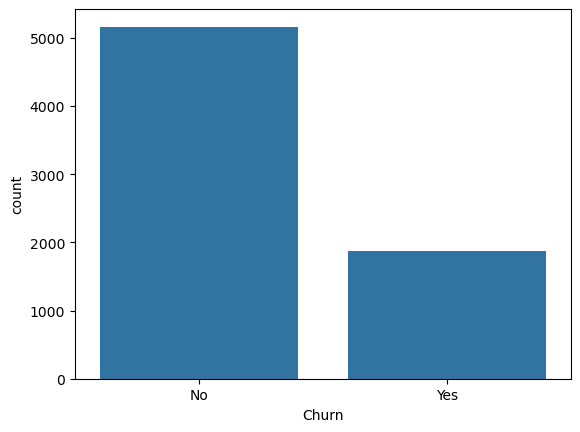

In [25]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x="Churn", data=df)
plt.show()

The dataset is slightly imbalanced, with around 26% churned customers.

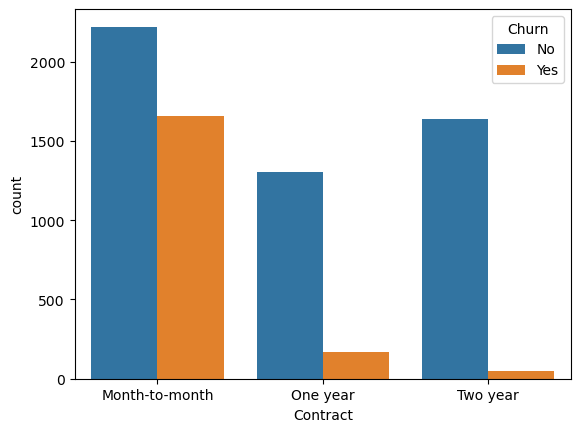

In [27]:
sns.countplot(x="Contract", hue="Churn", data=df)
plt.show()

Customers with month-to-month contracts show higher churn rates.

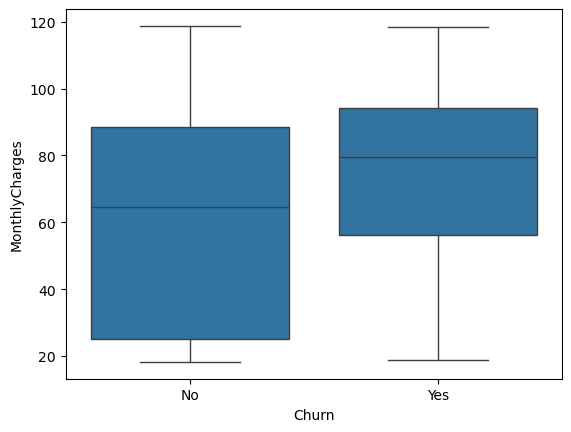

In [29]:
sns.boxplot(x="Churn", y="MonthlyCharges", data=df)
plt.show()

Monthly charges show variation between churned and retained customers.

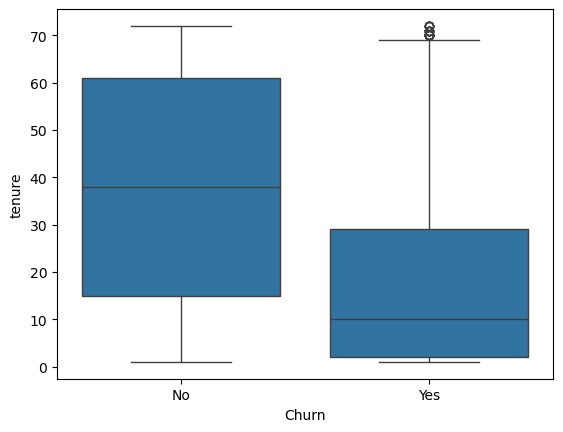

In [31]:
sns.boxplot(x="Churn", y="tenure", data=df)
plt.show()

Customers with shorter tenure are more likely to churn.

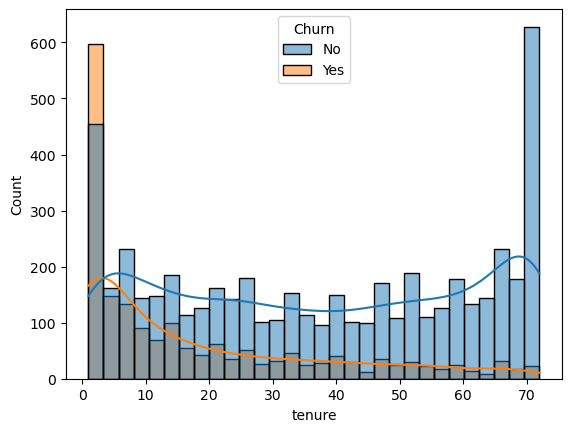

In [33]:
sns.histplot(data=df, x="tenure", hue="Churn", bins=30, kde=True)
plt.show()

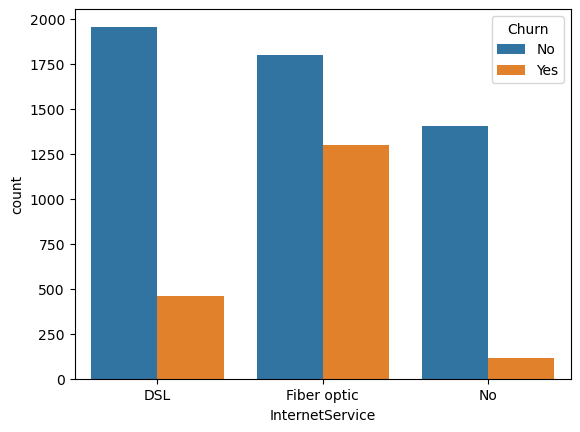

In [35]:
sns.countplot(x="InternetService", hue="Churn", data=df)
plt.show()

In [37]:
df = df.drop("customerID", axis=1)

In [39]:
df["Churn"] = df["Churn"].map({"Yes": 1, "No": 0})

In [41]:
df["Churn"].value_counts()

Churn
0    5163
1    1869
Name: count, dtype: int64

In [43]:
df = pd.get_dummies(df, drop_first=True)

We convert categorical variables into numeric format using one-hot encoding.

In [45]:
df.head()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,29.85,29.85,0,False,True,False,False,True,...,False,False,False,False,False,False,True,False,True,False
1,0,34,56.95,1889.50,0,True,False,False,True,False,...,False,False,False,False,True,False,False,False,False,True
2,0,2,53.85,108.15,1,True,False,False,True,False,...,False,False,False,False,False,False,True,False,False,True
3,0,45,42.30,1840.75,0,True,False,False,False,True,...,False,False,False,False,True,False,False,False,False,False
4,0,2,70.70,151.65,1,False,False,False,True,False,...,False,False,False,False,False,False,True,False,True,False


In [47]:
X = df.drop("Churn", axis=1)
y = df["Churn"]

In [60]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = LogisticRegression(max_iter=1000)
model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)

In [62]:
from sklearn.metrics import accuracy_score, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.7874911158493249
              precision    recall  f1-score   support

           0       0.83      0.89      0.86      1033
           1       0.62      0.52      0.56       374

    accuracy                           0.79      1407
   macro avg       0.73      0.70      0.71      1407
weighted avg       0.78      0.79      0.78      1407



The model achieves around 79% accuracy, but recall for churn is lower (~52%).

In [64]:
import pandas as pd

coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.coef_[0]
})

coefficients = coefficients.sort_values(by="Importance", ascending=False)

coefficients.head(10)

,Feature,Importance
3,TotalCharges,0.694885
10,InternetService_Fiber optic,0.650749
23,StreamingMovies_Yes,0.222440
21,StreamingTV_Yes,0.212963
9,MultipleLines_Yes,0.160546
26,PaperlessBilling_Yes,0.134580
28,PaymentMethod_Electronic check,0.123558
0,SeniorCitizen,0.094976
17,DeviceProtection_Yes,0.040129
8,MultipleLines_No phone service,0.029736


In [66]:
coefficients.tail(10)

,Feature,Importance
22,StreamingMovies_No internet service,-0.074068
14,OnlineBackup_No internet service,-0.074068
12,OnlineSecurity_No internet service,-0.074068
6,Dependents_Yes,-0.099848
19,TechSupport_Yes,-0.143482
13,OnlineSecurity_Yes,-0.155520
24,Contract_One year,-0.314562
25,Contract_Two year,-0.567396
2,MonthlyCharges,-0.632801
1,tenure,-1.445747


Key drivers of churn include fiber optic internet and total charges, while tenure and long-term contracts reduce churn.

## 📌 Conclusion

- Customers with short tenure are more likely to churn  
- Month-to-month contracts increase churn risk  
- Fiber optic users show higher churn rates  

## 💡 Business Recommendations

- Encourage long-term contracts  
- Offer incentives to new customers  
- Improve service quality for high-paying users  